In [1]:
import os

# Save the current PATH
original_path = os.environ['PATH']

# Set CUDA 12.5 environment variables, appending the original PATH explicitly
os.environ['CUDA_HOME'] = '/usr/local/cuda-12.5'
os.environ['PATH'] = f"/usr/local/cuda-12.5/bin:{original_path}"
os.environ['LD_LIBRARY_PATH'] = f"/usr/local/cuda-12.5/lib64:{os.environ.get('LD_LIBRARY_PATH', '')}"


In [2]:
import math
int(math.log(256, 2)) * 2 - 2

14

In [2]:
import os
HOME = os.getcwd()
print(HOME)

/home/ids/yuhe/Projects/CA_with_GAN/3_code_styleGAN/groundingdino


In [ ]:
#  %cd {HOME}
# !git clone https://github.com/IDEA-Research/GroundingDINO.git
# %cd {HOME}/GroundingDINO
# !pip install -q -e .
# !pip install -q roboflow

  DEPRECATION: Legacy editable install of groundingdino==0.1.0 from file:///home/ids/yuhe/Projects/CA_with_GAN/3_code_styleGAN/groundingdino/GroundingDINO (setup.py develop) is deprecated. pip 25.0 will enforce this behaviour change. A possible replacement is to add a pyproject.toml or enable --use-pep517, and use setuptools >= 64. If the resulting installation is not behaving as expected, try using --config-settings editable_mode=compat. Please consult the setuptools documentation for more information. Discussion can be found at https://github.com/pypa/pip/issues/11457


In [1]:


#CONFIG_PATH = os.path.join(HOME, "GroundingDINO/groundingdino/config/GroundingDINO_SwinT_OGC.py")

CONFIG_PATH = os.path.join(HOME, "GroundingDINO/groundingdino/config/GroundingDINO_SwinB_cfg.py")
print(CONFIG_PATH, "; exist:", os.path.isfile(CONFIG_PATH))

NameError: name 'os' is not defined

In [5]:
# %cd {HOME}
# !mkdir {HOME}/weights
# %cd {HOME}/weights

# !wget -q https://github.com/IDEA-Research/GroundingDINO/releases/download/v0.1.0-alpha/groundingdino_swint_ogc.pth
# # !wget -q https://github.com/IDEA-Research/GroundingDINO/releases/download/v0.1.0-alpha2/groundingdino_swinb_cogcoor.pth

In [6]:
WEIGHTS_NAME = "groundingdino_swinb_cogcoor.pth"
#WEIGHTS_NAME = "groundingdino_swint_ogc.pth"
WEIGHTS_PATH = os.path.join(HOME, "weights", WEIGHTS_NAME)
print(WEIGHTS_PATH, "; exist:", os.path.isfile(WEIGHTS_PATH))

/home/ids/yuhe/Projects/CA_with_GAN/3_code_styleGAN/groundingdino/weights/groundingdino_swinb_cogcoor.pth ; exist: True


In [7]:
# %cd {HOME}
# !mkdir {HOME}/data
# %cd {HOME}/data

# !wget -q https://media.roboflow.com/notebooks/examples/dog.jpeg
# !wget -q https://media.roboflow.com/notebooks/examples/dog-2.jpeg
# !wget -q https://media.roboflow.com/notebooks/examples/dog-3.jpeg
# !wget -q https://media.roboflow.com/notebooks/examples/dog-4.jpeg

In [8]:
%cd {HOME}/GroundingDINO

from groundingdino.util.inference import load_model, load_image, predict, annotate

model = load_model(CONFIG_PATH, WEIGHTS_PATH)

/home/ids/yuhe/Projects/CA_with_GAN/3_code_styleGAN/groundingdino/GroundingDINO


/home/ids/yuhe/anaconda3/envs/styleGANenv/lib/python3.11/site-packages/IPython/core/magics/osm.py:417: UserWarning: This is now an optional IPython functionality, setting dhist requires you to install the `pickleshare` library.
  self.shell.db['dhist'] = compress_dhist(dhist)[-100:]
2024-12-08 15:32:32.679005: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2024-12-08 15:32:33.680249: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT


ModuleNotFoundError: No module named 'yapf'

In [ ]:
data_path='/home/ids/yuhe/Projects/CA_with_GAN/2_data/styleGAN/ffhq_cs/test_t'
data_dirs = [os.path.join(data_path, f) for f in os.listdir(data_path) if f.endswith(".png")]


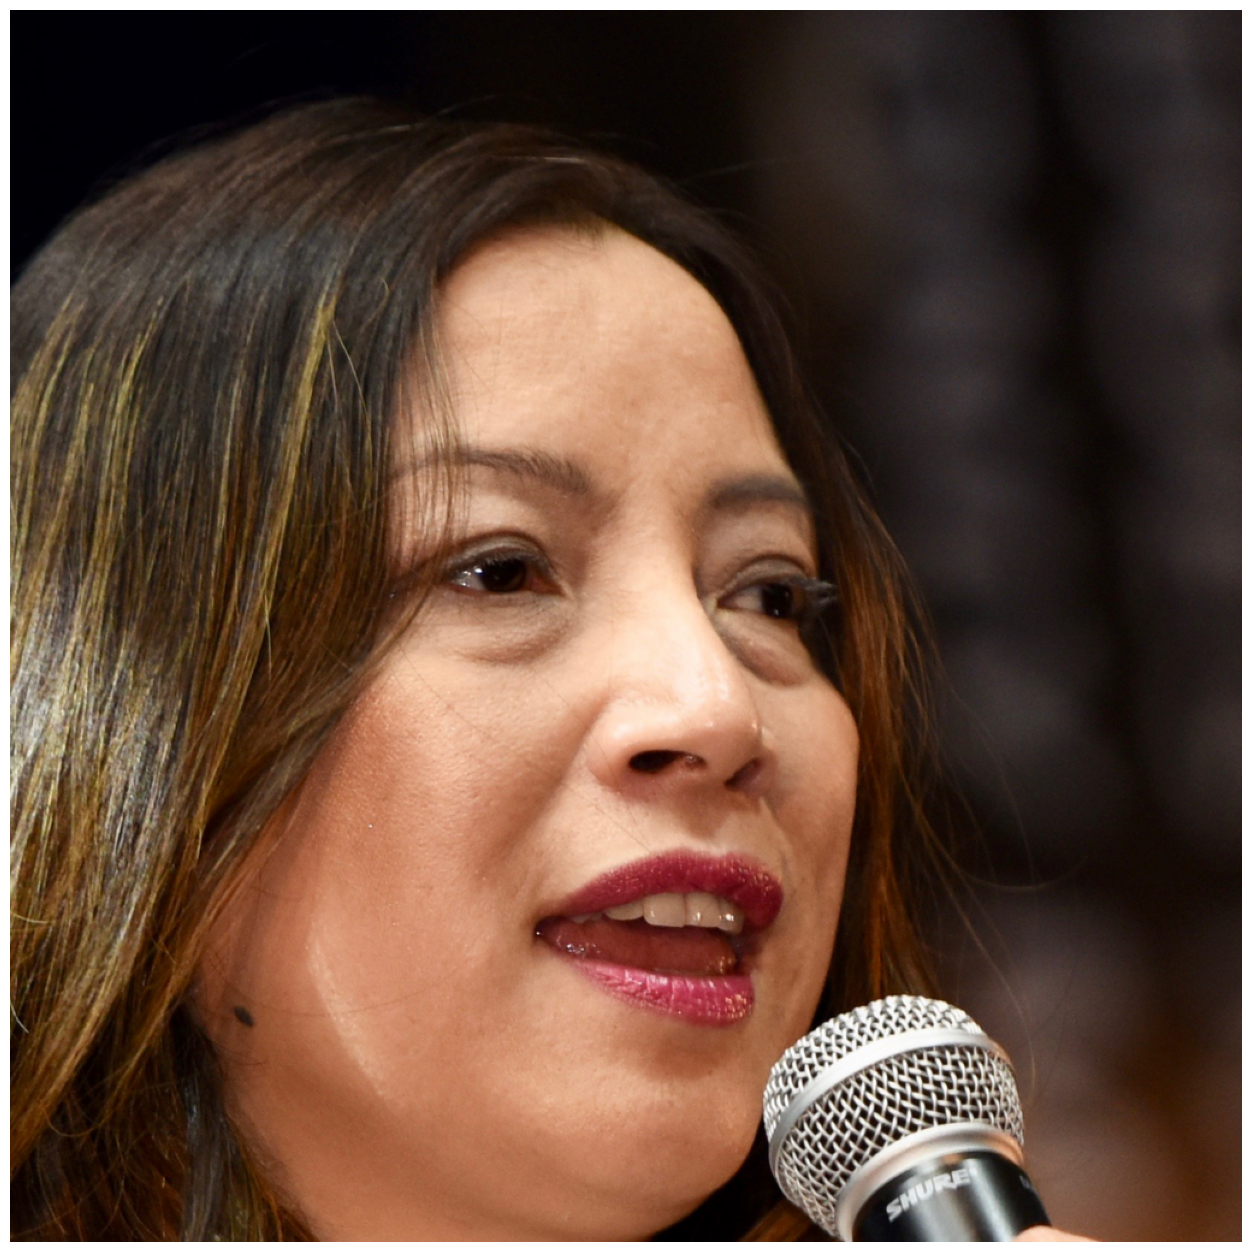

In [ ]:
import os
import supervision as sv
IMAGE_PATH = data_dirs[57]
# IMAGE_NAME = "dog-3.jpeg"
# IMAGE_PATH = os.path.join(HOME, "data", IMAGE_NAME)

TEXT_PROMPT = "glasses"
BOX_TRESHOLD = 0.45
TEXT_TRESHOLD = 0.25

image_source, image = load_image(IMAGE_PATH)

boxes, logits, phrases = predict(
    model=model, 
    image=image, 
    caption=TEXT_PROMPT, 
    box_threshold=BOX_TRESHOLD, 
    text_threshold=TEXT_TRESHOLD
)

annotated_frame = annotate(image_source=image_source, boxes=boxes, logits=logits, phrases=phrases)

%matplotlib inline  
sv.plot_image(annotated_frame, (16, 16))

In [ ]:
boxes

tensor([], size=(0, 4))